# Lab 1 — Facial Emotion Recognition on FER-2013
## Final Training & Evaluation Notebook — M1 + M2

This notebook consolidates the **executed outputs** from two successful training runs:

- **M1 — FERAttentionLite:** custom CNN trained from scratch.
- **M2 — MobileNetV3-Small:** ImageNet transfer learning.

### Final results

| Model | Test Accuracy | Macro F1 | Parameters | CPU Predictor FPS |
|---|---:|---:|---:|---:|
| M1 FERAttentionLite | **68.54%** | **0.6690** | **1,211,033** | **211.05** |
| M2 MobileNetV3-Small | **67.54%** | **0.6591** | **1,525,031** | **97.81** |

> The two model sections were executed independently and then consolidated into this required single `train.ipynb`. Existing outputs below are preserved from those successful runs.


# Part A — M1: FERAttentionLite (Custom CNN)


# PART A — M1: FERAttentionLite (Custom CNN)


In [1]:

# 1. Kiểm tra GPU Kaggle
!nvidia-smi


Tue Oct  6 15:17:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   67C    P0             29W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

# 2. Imports
import os
import json
import random
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from tqdm.auto import tqdm

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("GPU count:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")


PyTorch: 2.11.0+cu128
CUDA available: True
Device: cuda
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4



## 3. Cấu hình

Trên Kaggle, thêm FER-2013 dataset vào notebook rồi chỉnh `CSV_PATH`.

Notebook hỗ trợ định dạng CSV phổ biến:

```text
emotion,pixels,Usage
0,"70 80 82 ...",Training
...
```

với các split:
- `Training`
- `PublicTest`
- `PrivateTest`


In [3]:
# 3. Config — Run 2

SEED = 42
IMG_SIZE = 48
NUM_CLASSES = 7
BATCH_SIZE = 512 if torch.cuda.device_count() > 1 else 128
EPOCHS = 110
LR = 3e-4
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.02
NUM_WORKERS = 0

FER_LABELS = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral",
]

# ===== CHỈNH PATH NÀY NẾU CẦN =====
CSV_PATH = "/kaggle/input/fer2013/fer2013.csv"

OUTPUT_DIR = Path("/kaggle/working/m1_fer_attention_lite_2xt4")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

print("CSV_PATH:", CSV_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

PIN_MEMORY = torch.cuda.is_available()
USE_AMP = torch.cuda.is_available()
USE_MULTI_GPU = torch.cuda.device_count() > 1

print("M1 BATCH_SIZE:", BATCH_SIZE)
print("M1 NUM_WORKERS:", NUM_WORKERS)
print("M1 MULTI_GPU:", USE_MULTI_GPU)
print("M1 AMP:", USE_AMP)


CSV_PATH: /kaggle/input/fer2013/fer2013.csv
OUTPUT_DIR: /kaggle/working/m1_fer_attention_lite_2xt4
M1 BATCH_SIZE: 512
M1 NUM_WORKERS: 0
M1 MULTI_GPU: True
M1 AMP: True


In [4]:

# 4. Tự tìm fer2013.csv nếu path mặc định chưa đúng

if not Path(CSV_PATH).exists():
    found = list(Path("/kaggle/input").rglob("fer2013.csv"))
    if found:
        CSV_PATH = str(found[0])
        print("Found:", CSV_PATH)
    else:
        print("Không tìm thấy fer2013.csv.")
        print("Hãy Add Data trên Kaggle rồi sửa CSV_PATH.")
else:
    print("Dataset OK:", CSV_PATH)


Found: /kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/fer2013.csv


In [5]:

# 5. Đọc dữ liệu và kiểm tra split

df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())

print("\nColumns:", list(df.columns))
print("\nUsage:")
display(df["Usage"].value_counts())

print("\nClass distribution:")
class_counts = df["emotion"].value_counts().sort_index()
class_table = pd.DataFrame({
    "emotion_id": range(NUM_CLASSES),
    "label": FER_LABELS,
    "count": [class_counts.get(i, 0) for i in range(NUM_CLASSES)]
})
display(class_table)


Shape: (35887, 3)


,emotion,pixels,Usage
0,0,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...,Training
1,0,151 150 147 155 148 133 111 140 170 174 182 15...,Training
2,2,231 212 156 164 174 138 161 173 182 200 106 38...,Training
3,4,24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...,Training
4,6,4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...,Training



Columns: ['emotion', 'pixels', 'Usage']

Usage:


Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


Class distribution:


,emotion_id,label,count
0,0,Angry,4953
1,1,Disgust,547
2,2,Fear,5121
3,3,Happy,8989
4,4,Sad,6077
5,5,Surprise,4002
6,6,Neutral,6198


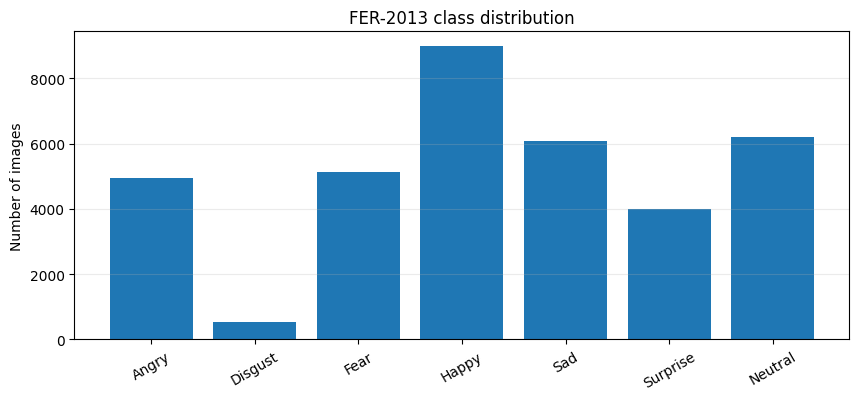

In [6]:

# 6. Vẽ phân bố lớp

plt.figure(figsize=(10, 4))
plt.bar(FER_LABELS, class_table["count"])
plt.title("FER-2013 class distribution")
plt.ylabel("Number of images")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.25)
plt.show()


In [7]:

# NOTE: If Kaggle multiprocessing is unstable, set NUM_WORKERS = 0 above.
# 7. Dataset + augmentation — Run 2

class FER2013Dataset(Dataset):
    def __init__(self, dataframe, split, transform=None):
        self.df = dataframe[dataframe["Usage"] == split].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pixels = np.fromstring(
            row["pixels"],
            dtype=np.uint8,
            sep=" "
        ).reshape(48, 48)

        image = transforms.functional.to_pil_image(pixels)
        label = int(row["emotion"])

        if self.transform:
            image = self.transform(image)

        return image, label


# Run 2: augmentation nhẹ hơn baseline
train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.97, 1.03),
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_tfms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_ds = FER2013Dataset(df, "Training", train_tfms)
val_ds   = FER2013Dataset(df, "PublicTest", eval_tfms)
test_ds  = FER2013Dataset(df, "PrivateTest", eval_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))


Train: 28709
Val  : 3589
Test : 3589


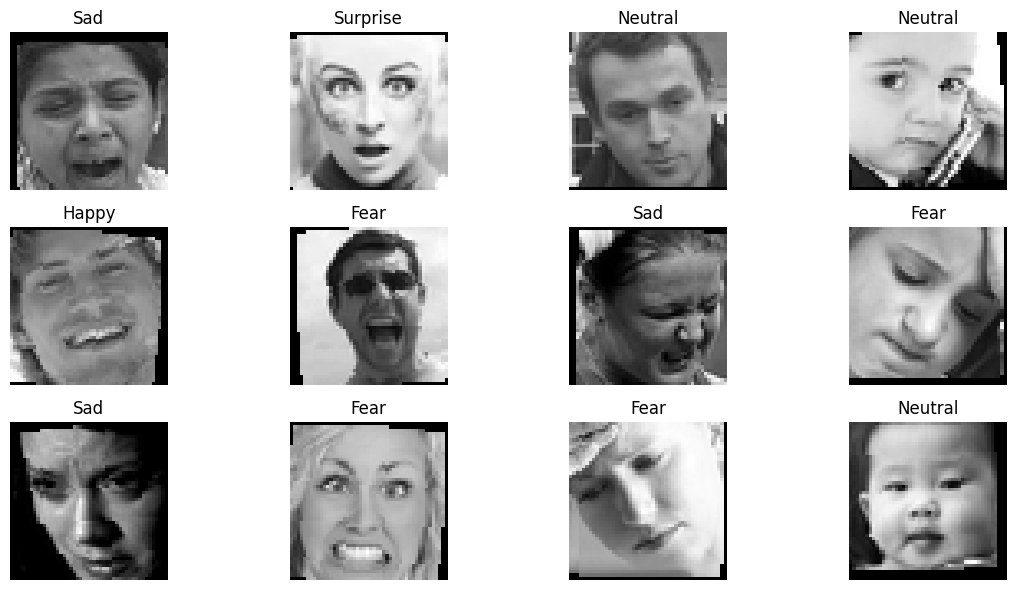

In [8]:

# 8. Xem vài ảnh

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    img = images[i, 0].numpy() * 0.5 + 0.5
    plt.imshow(img, cmap="gray")
    plt.title(FER_LABELS[int(labels[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()



## 9. Model — FERAttentionLite

Ý tưởng:
- Block 1–2 học feature thấp/trung cấp.
- Block 3 thêm:
  - **Channel attention:** feature map nào quan trọng?
  - **Spatial attention:** vùng nào trên mặt quan trọng?
- Block 4 học feature sâu hơn.
- Global Average Pooling giảm số tham số classifier.


In [9]:

# 9. Model

class ConvBNReLU(nn.Sequential):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__(
            nn.Conv2d(
                in_ch,
                out_ch,
                kernel_size=k,
                stride=s,
                padding=p,
                bias=False
            ),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.mlp = nn.Sequential(
            nn.Conv2d(channels, hidden, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        w = self.mlp(self.pool(x))
        return x * w


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.attn = nn.Sequential(
            nn.Conv2d(
                2,
                1,
                kernel_size=kernel_size,
                padding=kernel_size // 2,
                bias=False,
            ),
            nn.Sigmoid(),
        )

    def forward(self, x):
        avg_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)

        w = self.attn(
            torch.cat([avg_map, max_map], dim=1)
        )

        return x * w


class FERAttentionLite(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.block1 = nn.Sequential(
            ConvBNReLU(1, 32),
            ConvBNReLU(32, 32),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.10),
        )

        self.block2 = nn.Sequential(
            ConvBNReLU(32, 64),
            ConvBNReLU(64, 64),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.15),
        )

        self.block3_pre = nn.Sequential(
            ConvBNReLU(64, 128),
            ConvBNReLU(128, 128),
        )

        self.channel_attention = ChannelAttention(
            128,
            reduction=8
        )

        self.spatial_attention = SpatialAttention(
            kernel_size=7
        )

        self.block3_post = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Dropout2d(0.20),
        )

        self.block4 = nn.Sequential(
            ConvBNReLU(128, 256),
            ConvBNReLU(256, 256),
            nn.Dropout2d(0.25),
        )

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)

        x = self.block3_pre(x)
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        x = self.block3_post(x)

        x = self.block4(x)
        x = self.gap(x)

        return self.classifier(x)


base_model = FERAttentionLite(NUM_CLASSES).to(DEVICE)

if USE_MULTI_GPU:
    model = nn.DataParallel(base_model)
    print(f"Using DataParallel on {torch.cuda.device_count()} GPUs")
else:
    model = base_model

def unwrap_model(m):
    return m.module if isinstance(m, nn.DataParallel) else m

def model_state_for_save(m):
    # Save without the DataParallel "module." prefix.
    return unwrap_model(m).state_dict()

num_params = sum(
    p.numel()
    for p in unwrap_model(model).parameters()
    if p.requires_grad
)

print(unwrap_model(model))
print(f"\nTrainable parameters: {num_params:,}")

dummy = torch.randn(4, 1, 48, 48).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

print("Output shape:", out.shape)


Using DataParallel on 2 GPUs
FERAttentionLite(
  (block1): Sequential(
    (0): ConvBNReLU(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): ConvBNReLU(
      (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout2d(p=0.1, inplace=False)
  )
  (block2): Sequential(
    (0): ConvBNReLU(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): ConvBNReLU(
      (0): Conv2d(64, 64, kernel_size=(3, 3),

In [10]:
# 10. Soft class weights — Run 2

train_labels = train_ds.df["emotion"].to_numpy()
counts = np.bincount(train_labels, minlength=NUM_CLASSES)

# Baseline dùng inverse-frequency trực tiếp làm Disgust bị overweight mạnh.
# Run 2 dùng sqrt để vẫn hỗ trợ lớp hiếm nhưng mềm hơn.
weights = np.sqrt(
    counts.sum()
    / (NUM_CLASSES * np.maximum(counts, 1))
)

# Normalize mean ~ 1 để scale loss ổn định hơn
weights = weights / weights.mean()

class_weights = torch.tensor(
    weights,
    dtype=torch.float32,
    device=DEVICE
)

weight_table = pd.DataFrame({
    "class": FER_LABELS,
    "count": counts,
    "soft_weight": weights,
})

display(weight_table)


,class,count,soft_weight
0,Angry,3995,0.805754
1,Disgust,436,2.439032
2,Fear,4097,0.795661
3,Happy,7215,0.599574
4,Sad,4830,0.732803
5,Surprise,3171,0.904404
6,Neutral,4965,0.722772


In [11]:
# 11. Loss + optimizer + scheduler — Run 2

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=LABEL_SMOOTHING,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

# Giữ scheduler giống baseline để chỉ thay các yếu tố đã xác định
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6,
)

use_amp = USE_AMP

try:
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
    def amp_context():
        return torch.amp.autocast("cuda", enabled=use_amp)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    def amp_context():
        return torch.cuda.amp.autocast(enabled=use_amp)

print("AMP:", use_amp)
print("Label smoothing:", LABEL_SMOOTHING)


AMP: True
Label smoothing: 0.02


In [12]:

# 12. Evaluation function

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    total_loss = 0.0
    all_y = []
    all_pred = []
    all_probs = []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        logits = model(x)
        loss = nn.functional.cross_entropy(logits, y)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        total_loss += loss.item() * x.size(0)

        all_y.extend(y.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    acc = accuracy_score(all_y, all_pred)
    macro_f1 = f1_score(
        all_y,
        all_pred,
        average="macro"
    )

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": acc,
        "macro_f1": macro_f1,
        "y_true": np.array(all_y),
        "y_pred": np.array(all_pred),
        "probs": np.array(all_probs),
    }


## Run 1 baseline để đối chiếu

Baseline trước đó:

| Metric | Run 1 |
|---|---:|
| Validation Accuracy | 61.74% |
| Validation Macro F1 | 0.5665 |
| PrivateTest Accuracy | 64.00% |
| PrivateTest Macro F1 | 0.5910 |

Các lỗi đáng chú ý:
- **Fear recall thấp (~24%)**
- **Disgust recall rất cao nhưng precision thấp**, cho thấy model dự đoán Disgust quá nhiều

Run 2 chỉ chỉnh loss weighting, dropout và augmentation trước khi cân nhắc thay architecture.



## 13. Train

Checkpoint được chọn theo **validation macro F1**, thay vì chỉ accuracy.

Điều này phù hợp hơn với FER-2013 do phân bố lớp không cân bằng.


In [13]:

# 13. Training loop

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "lr": [],
}

best_f1 = -1.0
best_epoch = -1

for epoch in range(1, EPOCHS + 1):
    model.train()

    running_loss = 0.0
    seen = 0

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch:03d}/{EPOCHS}"
    )

    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with amp_context():
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * x.size(0)
        seen += x.size(0)

        pbar.set_postfix(
            loss=f"{running_loss / seen:.4f}"
        )

    scheduler.step()

    train_loss = running_loss / seen

    val_metrics = evaluate(
        model,
        val_loader
    )

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_macro_f1"].append(val_metrics["macro_f1"])
    history["lr"].append(current_lr)

    print(
        f"\nEpoch {epoch:03d} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['accuracy']*100:.2f}% | "
        f"val_f1={val_metrics['macro_f1']:.4f}"
    )

    if val_metrics["macro_f1"] > best_f1:
        best_f1 = val_metrics["macro_f1"]
        best_epoch = epoch

        torch.save(
            {
                "model_state": model_state_for_save(model),
                "epoch": epoch,
                "val_accuracy": val_metrics["accuracy"],
                "val_macro_f1": val_metrics["macro_f1"],
                "labels": FER_LABELS,
                "input_size": [1, 48, 48],
                "model_name": "FERAttentionLite",
                "batch_size": BATCH_SIZE,
                "gpu_count": torch.cuda.device_count(),
                "amp": USE_AMP,
            },
            OUTPUT_DIR / "best.pt",
        )

        print(
            f"✓ Saved new best.pt "
            f"(epoch={epoch}, macro_f1={best_f1:.4f})"
        )

    with open(
        OUTPUT_DIR / "history.json",
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(history, f, indent=2)

print("\nTraining complete")
print("Best epoch:", best_epoch)
print("Best validation Macro F1:", best_f1)


Epoch 001/110:   0%|          | 0/56 [00:00<?, ?it/s]


Epoch 001 | train_loss=1.9449 | val_loss=1.8097 | val_acc=27.58% | val_f1=0.1535
✓ Saved new best.pt (epoch=1, macro_f1=0.1535)


Epoch 002/110:   0%|          | 0/56 [00:00<?, ?it/s]


Epoch 002 | train_loss=1.8870 | val_loss=1.7289 | val_acc=32.32% | val_f1=0.2148
✓ Saved new best.pt (epoch=2, macro_f1=0.2148)


Epoch 003/110:   0%|          | 0/56 [00:00<?, ?it/s]

...


Epoch 108 | train_loss=0.9066 | val_loss=0.9201 | val_acc=66.70% | val_f1=0.6445


Epoch 109/110:   0%|          | 0/56 [00:00<?, ?it/s]


Epoch 109 | train_loss=0.9088 | val_loss=0.9186 | val_acc=66.43% | val_f1=0.6397


Epoch 110/110:   0%|          | 0/56 [00:00<?, ?it/s]


Epoch 110 | train_loss=0.9088 | val_loss=0.9172 | val_acc=66.73% | val_f1=0.6460

Training complete
Best epoch: 94
Best validation Macro F1: 0.6480484839607473


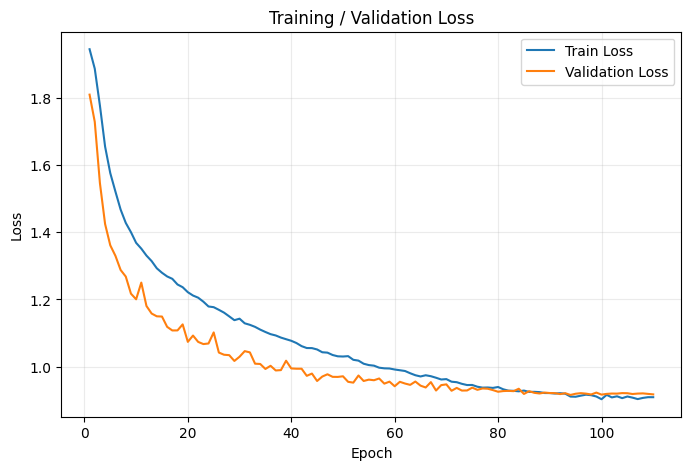

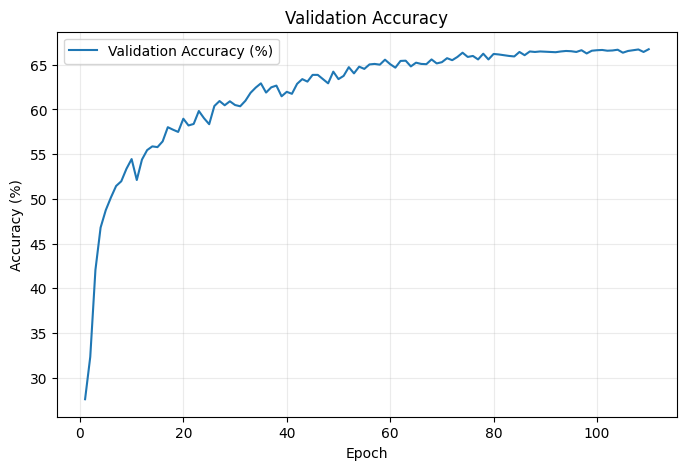

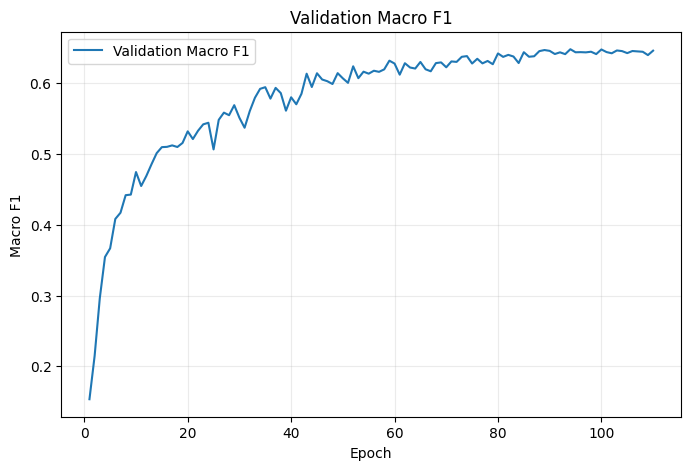

In [14]:

# 14. Learning curves

epochs_range = range(
    1,
    len(history["train_loss"]) + 1
)

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history["train_loss"],
    label="Train Loss"
)
plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training / Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    np.array(history["val_accuracy"]) * 100,
    label="Validation Accuracy (%)"
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs_range,
    history["val_macro_f1"],
    label="Validation Macro F1"
)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Validation Macro F1")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


In [15]:

# 15. Load best checkpoint

checkpoint = torch.load(
    OUTPUT_DIR / "best.pt",
    map_location=DEVICE
)

unwrap_model(model).load_state_dict(
    checkpoint["model_state"],
    strict=True
)

model.eval()

print("Loaded best checkpoint")
print("Epoch:", checkpoint["epoch"])
print(
    "Val accuracy:",
    f'{checkpoint["val_accuracy"]*100:.2f}%'
)
print(
    "Val macro F1:",
    f'{checkpoint["val_macro_f1"]:.4f}'
)


Loaded best checkpoint
Epoch: 94
Val accuracy: 66.54%
Val macro F1: 0.6480



## 16. Đánh giá trên PrivateTest

Không dùng `PrivateTest` để chọn checkpoint.

Chỉ đánh giá **một lần sau khi đã chọn model tốt nhất bằng PublicTest**.


In [16]:

# 16. Final test evaluation

test_metrics = evaluate(
    model,
    test_loader
)

print(
    f"PrivateTest Accuracy : "
    f"{test_metrics['accuracy']*100:.2f}%"
)
print(
    f"PrivateTest Macro F1 : "
    f"{test_metrics['macro_f1']:.4f}"
)

print("\nClassification report:\n")
print(
    classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=FER_LABELS,
        digits=4,
    )
)


PrivateTest Accuracy : 68.54%
PrivateTest Macro F1 : 0.6690

Classification report:

              precision    recall  f1-score   support

       Angry     0.6232    0.6232    0.6232       491
     Disgust     0.6232    0.7818    0.6935        55
        Fear     0.5702    0.3693    0.4483       528
       Happy     0.8867    0.8726    0.8796       879
         Sad     0.5310    0.6347    0.5782       594
    Surprise     0.7817    0.8005    0.7910       416
     Neutral     0.6399    0.7013    0.6692       626

    accuracy                         0.6854      3589
   macro avg     0.6651    0.6833    0.6690      3589
weighted avg     0.6860    0.6854    0.6814      3589



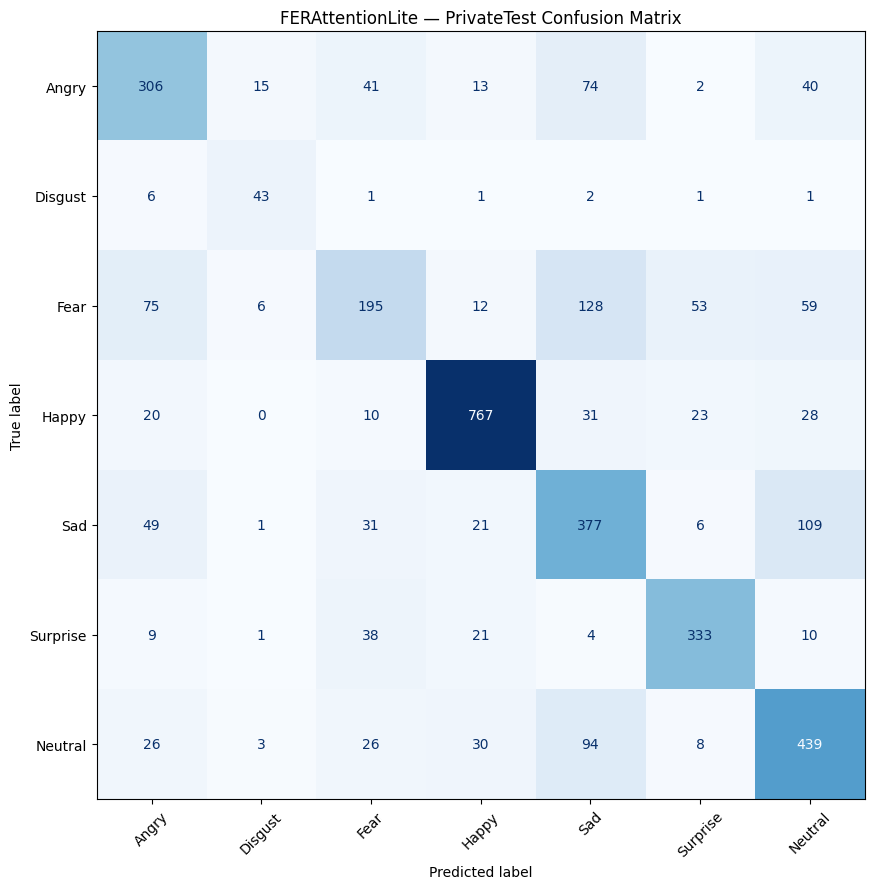

In [17]:

# 17. Confusion Matrix

cm = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"]
)

fig, ax = plt.subplots(figsize=(9, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=FER_LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d",
    colorbar=False
)

plt.title("FERAttentionLite — PrivateTest Confusion Matrix")
plt.tight_layout()
plt.show()



## 18. Phân tích ảnh dự đoán sai

Lab yêu cầu ít nhất 10 ảnh dự đoán sai kèm nhận xét.

Cell dưới hiển thị 20 mẫu sai có confidence cao để dễ phân tích.


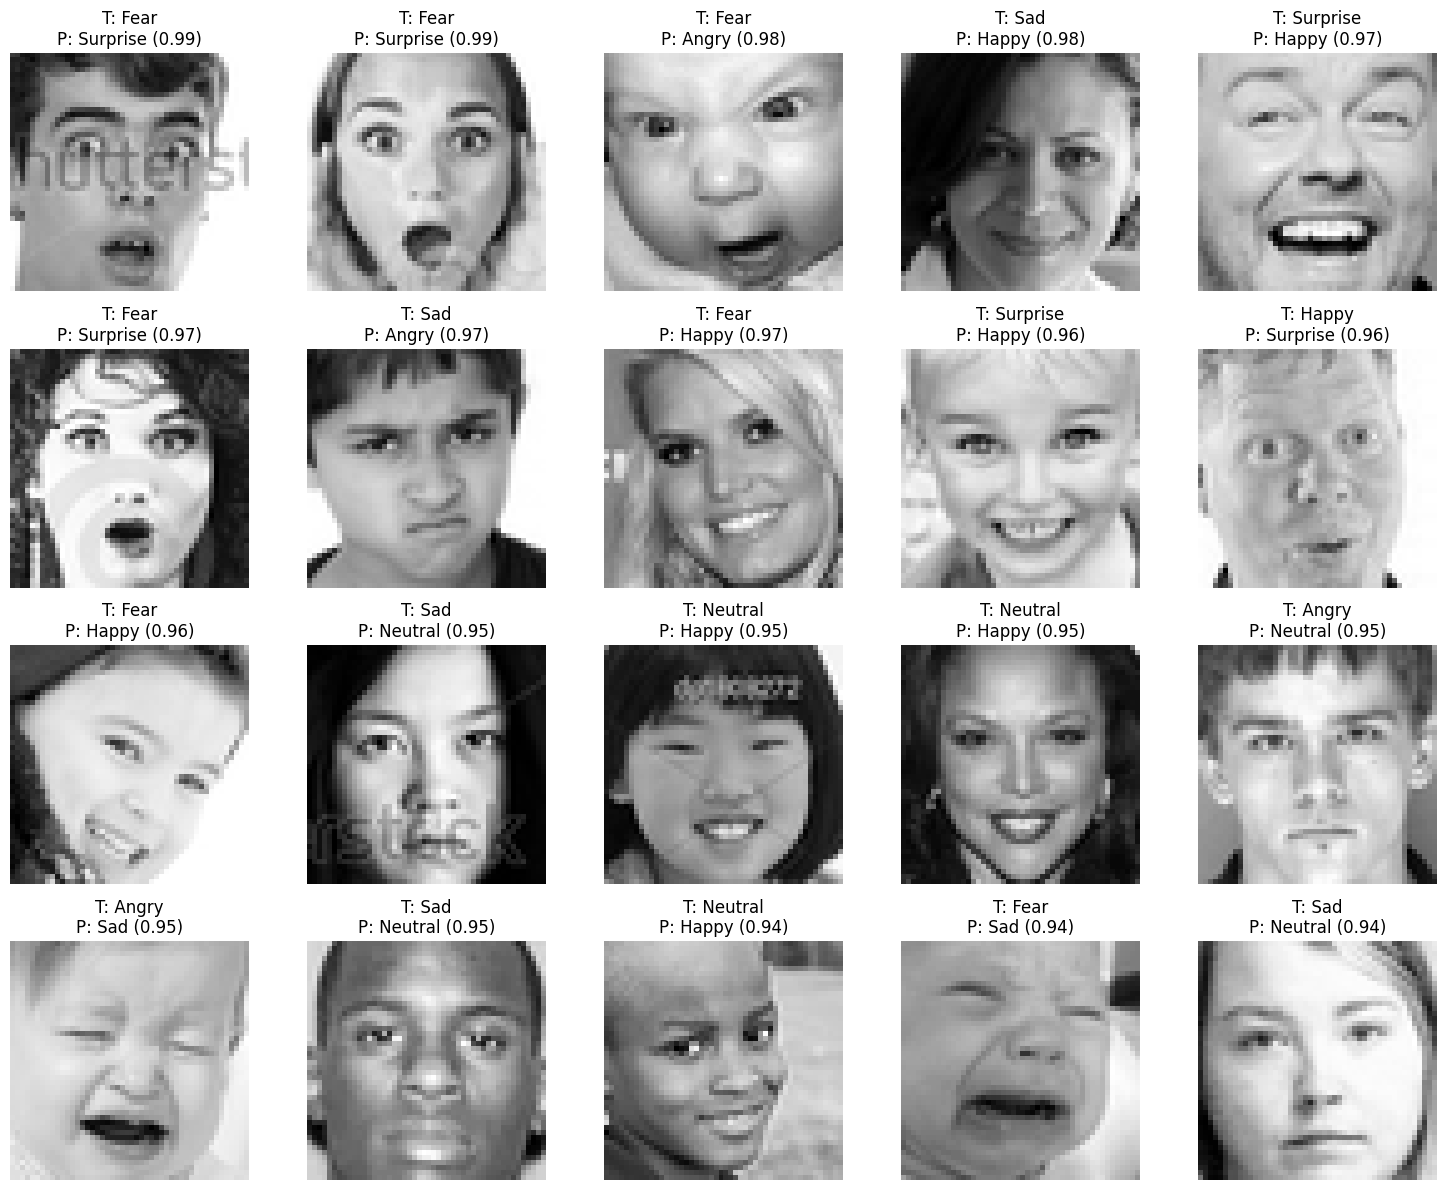

In [18]:

# 18. Show misclassified examples

y_true = test_metrics["y_true"]
y_pred = test_metrics["y_pred"]
probs = test_metrics["probs"]

wrong_idx = np.where(
    y_true != y_pred
)[0]

wrong_conf = probs[
    wrong_idx,
    y_pred[wrong_idx]
]

order = np.argsort(
    -wrong_conf
)

selected = wrong_idx[
    order[:20]
]

plt.figure(figsize=(15, 12))

for j, idx in enumerate(selected):
    img_tensor, true_label = test_ds[idx]

    img = (
        img_tensor[0].numpy() * 0.5 + 0.5
    )

    pred_label = y_pred[idx]
    confidence = probs[idx, pred_label]

    plt.subplot(4, 5, j + 1)
    plt.imshow(img, cmap="gray")
    plt.title(
        f"T: {FER_LABELS[true_label]}\n"
        f"P: {FER_LABELS[pred_label]} "
        f"({confidence:.2f})"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


In [19]:

# 19. Tóm tắt cặp lớp bị nhầm nhiều nhất

cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []

for true_idx in range(NUM_CLASSES):
    for pred_idx in range(NUM_CLASSES):
        if true_idx != pred_idx:
            pairs.append(
                (
                    cm_no_diag[true_idx, pred_idx],
                    FER_LABELS[true_idx],
                    FER_LABELS[pred_idx],
                )
            )

pairs = sorted(
    pairs,
    reverse=True
)

print("Top confusion pairs:")

for count, true_name, pred_name in pairs[:10]:
    print(
        f"{true_name:>9s} -> "
        f"{pred_name:<9s}: {count}"
    )


Top confusion pairs:
     Fear -> Sad      : 128
      Sad -> Neutral  : 109
  Neutral -> Sad      : 94
     Fear -> Angry    : 75
    Angry -> Sad      : 74
     Fear -> Neutral  : 59
     Fear -> Surprise : 53
      Sad -> Angry    : 49
    Angry -> Fear     : 41
    Angry -> Neutral  : 40



## 20. GPU inference benchmark

Đây chỉ là benchmark trong Kaggle.

FPS CPU thực tế phải đo lại sau khi tải `best.pt` về laptop.


In [20]:
# 20. M1 CPU classifier benchmark

cpu_m1 = copy.deepcopy(
    unwrap_model(model)
).cpu().eval()

x_cpu = torch.randn(1, 1, 48, 48)

with torch.inference_mode():
    for _ in range(50):
        _ = cpu_m1(x_cpu)

times = []
with torch.inference_mode():
    for _ in range(300):
        t0 = time.perf_counter()
        _ = cpu_m1(x_cpu)
        times.append(time.perf_counter() - t0)

m1_latency_ms = float(np.mean(times) * 1000.0)
m1_cpu_fps = float(1.0 / np.mean(times))

print(f"M1 CPU latency: {m1_latency_ms:.2f} ms/face")
print(f"M1 classifier FPS: {m1_cpu_fps:.2f}")
print("Classifier FPS != full realtime pipeline FPS.")


M1 CPU latency: 4.74 ms/face
M1 classifier FPS: 211.05
Classifier FPS != full realtime pipeline FPS.


In [21]:

# 21. Export kết quả

m1_summary = {
    "model": "FERAttentionLite",
    "best_epoch": int(checkpoint["epoch"]),
    "val_accuracy": float(checkpoint["val_accuracy"]),
    "val_macro_f1": float(checkpoint["val_macro_f1"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "trainable_parameters": int(num_params),
    "cpu_latency_ms_per_face": float(m1_latency_ms),
    "classifier_fps_cpu": float(m1_cpu_fps),
    "batch_size": int(BATCH_SIZE),
    "gpu_count": int(torch.cuda.device_count()),
    "amp": bool(USE_AMP),
    "labels": FER_LABELS,
}

with open(
    OUTPUT_DIR / "FINAL_SUMMARY.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        m1_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print(json.dumps(
    m1_summary,
    indent=2,
    ensure_ascii=False
))

print("\nFiles:")
for p in OUTPUT_DIR.iterdir():
    print("-", p.name)


{
  "model": "FERAttentionLite",
  "best_epoch": 94,
  "val_accuracy": 0.6653663973251602,
  "val_macro_f1": 0.6480484839607473,
  "test_accuracy": 0.685427695736974,
  "test_macro_f1": 0.6690044822055443,
  "trainable_parameters": 1211033,
  "cpu_latency_ms_per_face": 4.738305229978627,
  "classifier_fps_cpu": 211.04592284877157,
  "batch_size": 512,
  "gpu_count": 2,
  "amp": true,
  "labels": [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
  ]
}

Files:
- history.json
- FINAL_SUMMARY.json
- best.pt



## 22. File cần tải về laptop

Sau khi train xong, tải:

```text
/kaggle/working/fer_attention_lite/best.pt
```

Checkpoint này sẽ được dùng cho:

```text
IP Camera
   ↓
Face Detector
   ↓
48×48 grayscale
   ↓
FERAttentionLite
   ↓
Emotion + Confidence
```

Sau đó mới benchmark **CPU FPS trên laptop**.


## 23. So sánh Run 2 với baseline

Sau khi chạy xong, kiểm tra:

- PrivateTest Accuracy có vượt **64.00%** không?
- Macro F1 có vượt **0.5910** không?
- Fear recall có tăng rõ không?
- Disgust precision có tăng không?
- Confusion `Fear -> Sad`, `Fear -> Surprise`, `Sad -> Neutral` có giảm không?

Nếu Accuracy đạt khoảng **66–68%** và Macro F1 tăng, giữ Run 2 làm checkpoint mới.


In [22]:
# 23. Quick comparison with Run 1

baseline = {
    "test_accuracy": 0.6400,
    "test_macro_f1": 0.5910,
}

print("=== Run 1 baseline ===")
print(f"Accuracy : {baseline['test_accuracy']*100:.2f}%")
print(f"Macro F1 : {baseline['test_macro_f1']:.4f}")

print("\n=== Run 2 ===")
print(f"Accuracy : {test_metrics['accuracy']*100:.2f}%")
print(f"Macro F1 : {test_metrics['macro_f1']:.4f}")

print("\n=== Delta ===")
print(f"Accuracy : {(test_metrics['accuracy']-baseline['test_accuracy'])*100:+.2f} points")
print(f"Macro F1 : {test_metrics['macro_f1']-baseline['test_macro_f1']:+.4f}")


=== Run 1 baseline ===
Accuracy : 64.00%
Macro F1 : 0.5910

=== Run 2 ===
Accuracy : 68.54%
Macro F1 : 0.6690

=== Delta ===
Accuracy : +4.54 points
Macro F1 : +0.0780


### M1 final result

- Test Accuracy: **68.54%**
- Macro F1: **0.6690**
- Parameters: **1,211,033**
- CPU Predictor FPS: **211.05**

M1 directly uses FER-2013 grayscale 48×48 images and combines convolutional blocks with channel and spatial attention.


# Part B — M2: MobileNetV3-Small Transfer Learning


In [23]:

# 1. GPU / environment
!nvidia-smi

import json
import random
import time
import copy
from pathlib import Path
from contextlib import nullcontext

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from tqdm.auto import tqdm

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
print("GPU count visible:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))


Tue Oct  6 18:48:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.178.04             Driver Version: 580.178.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [24]:

# 2. Configuration

SEED = 42
NUM_CLASSES = 7
IMG_SIZE = 224

# Stable setting for one T4.
BATCH_SIZE = 128
NUM_WORKERS = 0

STAGE1_EPOCHS = 5
STAGE2_EPOCHS = 35
EARLY_STOP_PATIENCE = 10

USE_AMP = torch.cuda.is_available()

FER_LABELS = [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral",
]

CSV_PATH = "/kaggle/input/fer2013/fer2013.csv"
OUTPUT_DIR = Path("/kaggle/working/m2_mobilenetv3_rerun_clean")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # benchmark=True is fast for fixed-size 224x224 inputs.
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)

if not Path(CSV_PATH).exists():
    matches = list(Path("/kaggle/input").rglob("fer2013.csv"))
    if not matches:
        raise FileNotFoundError(
            "Không tìm thấy fer2013.csv. Hãy Add Data FER-2013 vào Kaggle notebook."
        )
    CSV_PATH = str(matches[0])

print("CSV:", CSV_PATH)
print("Output:", OUTPUT_DIR)
print("Batch:", BATCH_SIZE)
print("AMP:", USE_AMP)


CSV: /kaggle/input/datasets/ashishpatel26/facial-expression-recognitionferchallenge/fer2013/fer2013/fer2013.csv
Output: /kaggle/working/m2_mobilenetv3_rerun_clean
Batch: 128
AMP: True


Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


,class_id,label,training_count
0,0,Angry,3995
1,1,Disgust,436
2,2,Fear,4097
3,3,Happy,7215
4,4,Sad,4830
5,5,Surprise,3171
6,6,Neutral,4965


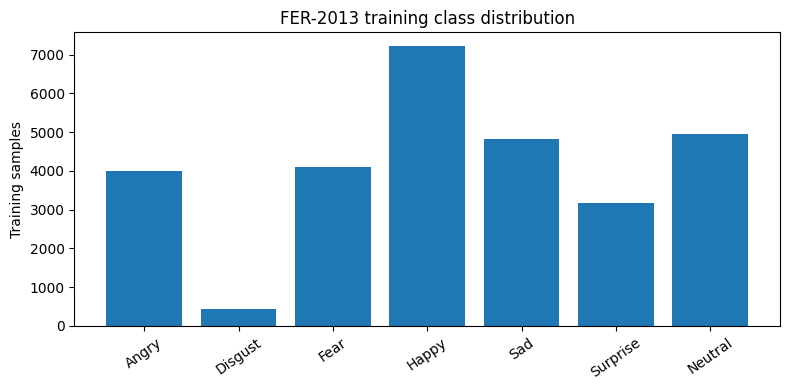

In [25]:

# 3. Load FER-2013 and inspect class distribution

df = pd.read_csv(CSV_PATH)

print(df["Usage"].value_counts())

train_counts = (
    df[df["Usage"] == "Training"]["emotion"]
    .value_counts()
    .sort_index()
)

distribution = pd.DataFrame({
    "class_id": range(NUM_CLASSES),
    "label": FER_LABELS,
    "training_count": [
        int(train_counts.get(i, 0))
        for i in range(NUM_CLASSES)
    ],
})

display(distribution)

plt.figure(figsize=(8, 4))
plt.bar(distribution["label"], distribution["training_count"])
plt.xticks(rotation=35)
plt.ylabel("Training samples")
plt.title("FER-2013 training class distribution")
plt.tight_layout()
plt.show()


In [26]:

# 4. Dataset

class FER2013Dataset(Dataset):
    def __init__(self, dataframe, split, transform=None):
        self.df = dataframe[
            dataframe["Usage"] == split
        ].reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        pixels = np.fromstring(
            row["pixels"],
            dtype=np.uint8,
            sep=" ",
        ).reshape(48, 48)

        image = transforms.functional.to_pil_image(pixels)

        # ImageNet-pretrained MobileNetV3 expects 3 channels.
        image = image.convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        label = int(row["emotion"])
        return image, label


In [27]:

# 5. Preprocessing and augmentation

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(7),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.97, 1.03),
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = FER2013Dataset(df, "Training", train_tfms)
val_ds = FER2013Dataset(df, "PublicTest", eval_tfms)
test_ds = FER2013Dataset(df, "PrivateTest", eval_tfms)

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    drop_last=True,
    generator=g,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train:", len(train_ds))
print("Val  :", len(val_ds))
print("Test :", len(test_ds))
print("Train steps/epoch:", len(train_loader))


Train: 28709
Val  : 3589
Test : 3589
Train steps/epoch: 224


In [28]:

# 6. Soft class weights for FER-2013 imbalance

train_labels = train_ds.df["emotion"].to_numpy()
counts = np.bincount(train_labels, minlength=NUM_CLASSES)

# Mild weighting. Full inverse-frequency over-emphasizes rare Disgust.
WEIGHT_POWER = 0.25

weights_np = (
    counts.sum()
    / (NUM_CLASSES * np.maximum(counts, 1))
) ** WEIGHT_POWER

weights_np = weights_np / weights_np.mean()

class_weights = torch.tensor(
    weights_np,
    dtype=torch.float32,
    device=DEVICE,
)

for name, count, weight in zip(FER_LABELS, counts, weights_np):
    print(f"{name:10s} count={count:5d} weight={weight:.4f}")


Angry      count= 3995 weight=0.9264
Disgust    count=  436 weight=1.6117
Fear       count= 4097 weight=0.9205
Happy      count= 7215 weight=0.7991
Sad        count= 4830 weight=0.8834
Surprise   count= 3171 weight=0.9814
Neutral    count= 4965 weight=0.8774


In [29]:

# 7. Build MobileNetV3-Small pretrained on ImageNet

model = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.DEFAULT
)

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)

PARAM_COUNT = sum(p.numel() for p in model.parameters())

print(model.classifier)
print(f"Parameters: {PARAM_COUNT:,}")


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 105MB/s]

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=7, bias=True)
)
Parameters: 1,525,031


In [30]:

# 8. Loss, AMP helpers, evaluation

criterion_train = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.02,
)

# Plain CE is used only for interpretable validation/test loss.
criterion_eval = nn.CrossEntropyLoss()

if USE_AMP:
    scaler = torch.amp.GradScaler("cuda")
else:
    scaler = None

def autocast_context():
    if USE_AMP:
        return torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16,
        )
    return nullcontext()

@torch.no_grad()
def evaluate(model, loader):
    model.eval()

    ys = []
    preds = []
    total_loss = 0.0

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        with autocast_context():
            logits = model(x)
            loss = criterion_eval(logits, y)

        pred = logits.argmax(dim=1)

        total_loss += loss.item() * x.size(0)
        ys.extend(y.cpu().numpy())
        preds.extend(pred.cpu().numpy())

    y_true = np.asarray(ys)
    y_pred = np.asarray(preds)

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "y_true": y_true,
        "y_pred": y_pred,
    }

def selection_score(metrics):
    # Use only validation metrics for checkpoint selection.
    return 0.5 * metrics["accuracy"] + 0.5 * metrics["macro_f1"]


In [31]:

# 9. Training helper

def save_checkpoint(
    model,
    path,
    epoch,
    stage,
    val_metrics,
):
    torch.save({
        "model_state": model.state_dict(),
        "epoch": int(epoch),
        "stage": stage,
        "val_accuracy": float(val_metrics["accuracy"]),
        "val_macro_f1": float(val_metrics["macro_f1"]),
        "selection_score": float(selection_score(val_metrics)),
        "labels": FER_LABELS,
        "input_size": [3, IMG_SIZE, IMG_SIZE],
        "model_name": "MobileNetV3Small",
        "pretrained": "ImageNet",
        "batch_size": BATCH_SIZE,
        "gpu_count": 1 if torch.cuda.is_available() else 0,
        "amp": USE_AMP,
    }, path)

def train_stage(
    model,
    optimizer,
    scheduler,
    start_epoch,
    epochs,
    history,
    stage_name,
    freeze_backbone_bn=False,
    initial_best_score=-1.0,
    patience=None,
):
    best_score = float(initial_best_score)
    best_epoch = None
    bad_epochs = 0

    for epoch in range(start_epoch, start_epoch + epochs):
        model.train()

        # Critical for Stage 1:
        # frozen pretrained feature extractor stays in eval mode so BN
        # running statistics are not modified while its weights are frozen.
        if freeze_backbone_bn:
            model.features.eval()

        running_loss = 0.0
        seen = 0
        correct = 0

        pbar = tqdm(
            train_loader,
            desc=f"{stage_name} epoch {epoch:03d}",
        )

        for x, y in pbar:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast_context():
                logits = model(x)
                loss = criterion_train(logits, y)

            if USE_AMP:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0,
                )
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0,
                )
                optimizer.step()

            running_loss += loss.item() * x.size(0)
            seen += x.size(0)

            pred = logits.argmax(dim=1)
            correct += (pred == y).sum().item()

            pbar.set_postfix(
                loss=f"{running_loss / seen:.4f}",
                acc=f"{100 * correct / seen:.2f}%",
            )

        train_loss = running_loss / seen
        train_acc = correct / seen

        val = evaluate(model, val_loader)
        score = selection_score(val)

        history.append({
            "epoch": epoch,
            "stage": stage_name,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val["loss"],
            "val_accuracy": val["accuracy"],
            "val_macro_f1": val["macro_f1"],
            "selection_score": score,
            "lr_backbone": optimizer.param_groups[0]["lr"],
            "lr_head": optimizer.param_groups[-1]["lr"],
        })

        print(
            f"Epoch {epoch:03d} | "
            f"train_acc={train_acc*100:.2f}% | "
            f"val_acc={val['accuracy']*100:.2f}% | "
            f"val_f1={val['macro_f1']:.4f} | "
            f"score={score:.4f}"
        )

        if score > best_score:
            best_score = score
            best_epoch = epoch
            bad_epochs = 0

            save_checkpoint(
                model,
                OUTPUT_DIR / "best.pt",
                epoch,
                stage_name,
                val,
            )
            print("✓ saved new best.pt")
        else:
            bad_epochs += 1

        pd.DataFrame(history).to_csv(
            OUTPUT_DIR / "history.csv",
            index=False,
        )

        if scheduler is not None:
            scheduler.step()

        if patience is not None and bad_epochs >= patience:
            print(
                f"Early stopping: no validation improvement "
                f"for {patience} epochs."
            )
            break

    return best_score, best_epoch, history



## 10. Stage 1 — train classifier head only

Backbone weights are frozen. The feature extractor is also held in `eval()` mode during each training epoch so pretrained BatchNorm running statistics remain fixed.


In [32]:

# 10. Stage 1

for p in model.features.parameters():
    p.requires_grad = False

for p in model.classifier.parameters():
    p.requires_grad = True

print(
    "Trainable parameters Stage 1:",
    sum(p.numel() for p in model.parameters() if p.requires_grad)
)

optimizer1 = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

scheduler1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer1,
    T_max=STAGE1_EPOCHS,
    eta_min=1e-5,
)

history = []

best_score, stage1_best_epoch, history = train_stage(
    model=model,
    optimizer=optimizer1,
    scheduler=scheduler1,
    start_epoch=1,
    epochs=STAGE1_EPOCHS,
    history=history,
    stage_name="head",
    freeze_backbone_bn=True,
    initial_best_score=-1.0,
    patience=None,
)

print("Stage 1 best epoch:", stage1_best_epoch)
print("Stage 1 best selection score:", best_score)


Trainable parameters Stage 1: 598023


head epoch 001:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 001 | train_acc=44.16% | val_acc=47.45% | val_f1=0.4018 | score=0.4382
✓ saved new best.pt


head epoch 002:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 002 | train_acc=50.72% | val_acc=49.35% | val_f1=0.4399 | score=0.4667
✓ saved new best.pt


...

Epoch 003 | train_acc=52.68% | val_acc=49.57% | val_f1=0.4519 | score=0.4738
✓ saved new best.pt


head epoch 004:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 004 | train_acc=54.36% | val_acc=51.04% | val_f1=0.4632 | score=0.4868
✓ saved new best.pt


head epoch 005:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 005 | train_acc=55.35% | val_acc=51.71% | val_f1=0.4678 | score=0.4925
✓ saved new best.pt
Stage 1 best epoch: 5
Stage 1 best selection score: 0.49246683071619324



## 11. Stage 2 — full fine-tuning

Load the best Stage 1 checkpoint, unfreeze all layers, then fine-tune the pretrained backbone with a smaller learning rate than the classifier.


In [33]:

# 11. Stage 2

stage1_ckpt = torch.load(
    OUTPUT_DIR / "best.pt",
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    stage1_ckpt["model_state"],
    strict=True,
)

for p in model.parameters():
    p.requires_grad = True

optimizer2 = torch.optim.AdamW([
    {
        "params": model.features.parameters(),
        "lr": 5e-5,
    },
    {
        "params": model.classifier.parameters(),
        "lr": 2e-4,
    },
], weight_decay=1e-4)

scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer2,
    T_max=STAGE2_EPOCHS,
    eta_min=1e-6,
)

best_score = float(stage1_ckpt["selection_score"])

best_score, stage2_best_epoch, history = train_stage(
    model=model,
    optimizer=optimizer2,
    scheduler=scheduler2,
    start_epoch=STAGE1_EPOCHS + 1,
    epochs=STAGE2_EPOCHS,
    history=history,
    stage_name="finetune",
    freeze_backbone_bn=False,
    initial_best_score=best_score,
    patience=EARLY_STOP_PATIENCE,
)

print("Stage 2 best epoch:", stage2_best_epoch)
print("Final best selection score:", best_score)


finetune epoch 006:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 006 | train_acc=44.68% | val_acc=44.94% | val_f1=0.3621 | score=0.4058


finetune epoch 007:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 007 | train_acc=54.73% | val_acc=55.03% | val_f1=0.4992 | score=0.5248
✓ saved new best.pt


finetune epoch 008:   0%|          | 0/224 [00:00<?, ?it/s]

...

Epoch 038 | train_acc=78.66% | val_acc=65.81% | val_f1=0.6405 | score=0.6493


finetune epoch 039:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 039 | train_acc=78.72% | val_acc=65.59% | val_f1=0.6385 | score=0.6472


finetune epoch 040:   0%|          | 0/224 [00:00<?, ?it/s]

Epoch 040 | train_acc=78.80% | val_acc=65.59% | val_f1=0.6406 | score=0.6482
Stage 2 best epoch: 33
Final best selection score: 0.6499984993057333


,epoch,stage,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_f1,selection_score,lr_backbone,lr_head
35,36,finetune,0.699732,0.785226,0.982173,0.654778,0.637402,0.646090,0.000003,0.000011
36,37,finetune,0.698766,0.783691,0.981749,0.654778,0.637125,0.645952,0.000003,0.000007
37,38,finetune,0.695074,0.786621,0.982415,0.658122,0.640507,0.649315,0.000002,0.000005
38,39,finetune,0.695157,0.787179,0.982905,0.655893,0.638513,0.647203,0.000001,0.000003
39,40,finetune,0.693261,0.788016,0.983377,0.655893,0.640590,0.648241,0.000001,0.000001


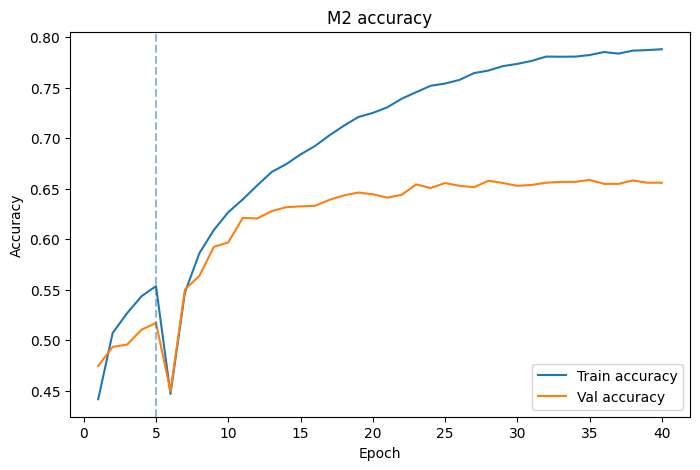

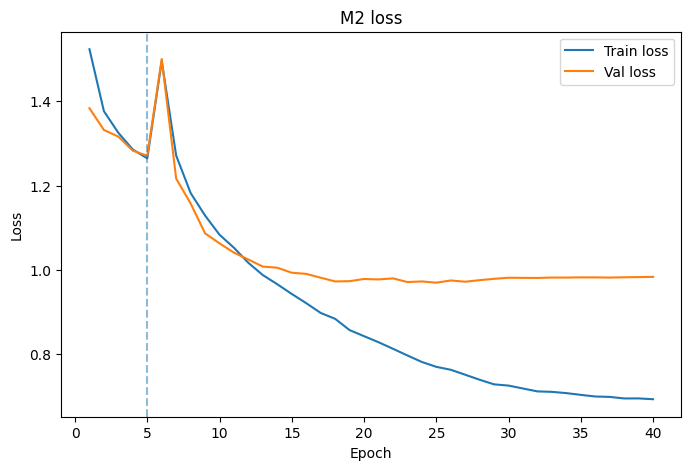

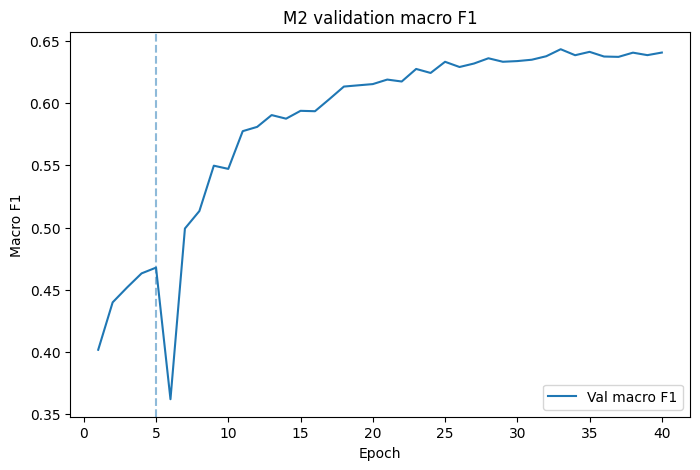

In [34]:

# 12. Training curves

hist = pd.DataFrame(history)
display(hist.tail())

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_accuracy"], label="Train accuracy")
plt.plot(hist["epoch"], hist["val_accuracy"], label="Val accuracy")
plt.axvline(STAGE1_EPOCHS, linestyle="--", alpha=0.5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("M2 accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="Train loss")
plt.plot(hist["epoch"], hist["val_loss"], label="Val loss")
plt.axvline(STAGE1_EPOCHS, linestyle="--", alpha=0.5)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("M2 loss")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["val_macro_f1"], label="Val macro F1")
plt.axvline(STAGE1_EPOCHS, linestyle="--", alpha=0.5)
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("M2 validation macro F1")
plt.legend()
plt.show()



## 13. Final evaluation on PrivateTest

PrivateTest is evaluated only after model selection is complete.


In [35]:

# 13. Final PrivateTest evaluation

best_ckpt = torch.load(
    OUTPUT_DIR / "best.pt",
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_ckpt["model_state"],
    strict=True,
)

model.eval()

test_metrics = evaluate(model, test_loader)

print("=== FINAL M2 ===")
print("Best epoch       :", best_ckpt["epoch"])
print("Best stage       :", best_ckpt["stage"])
print(f"Val Accuracy     : {best_ckpt['val_accuracy']*100:.2f}%")
print(f"Val Macro F1     : {best_ckpt['val_macro_f1']:.4f}")
print(f"Test Accuracy    : {test_metrics['accuracy']*100:.2f}%")
print(f"Test Macro F1    : {test_metrics['macro_f1']:.4f}")
print(f"Parameters       : {PARAM_COUNT:,}")


=== FINAL M2 ===
Best epoch       : 33
Best stage       : finetune
Val Accuracy     : 65.67%
Val Macro F1     : 0.6433
Test Accuracy    : 67.54%
Test Macro F1    : 0.6591
Parameters       : 1,525,031


In [36]:

# 14. Classification report

print(
    classification_report(
        test_metrics["y_true"],
        test_metrics["y_pred"],
        target_names=FER_LABELS,
        digits=4,
    )
)


              precision    recall  f1-score   support

       Angry     0.5920    0.5703    0.5809       491
     Disgust     0.6667    0.6545    0.6606        55
        Fear     0.5572    0.4981    0.5260       528
       Happy     0.8757    0.8817    0.8787       879
         Sad     0.5312    0.5724    0.5511       594
    Surprise     0.8000    0.7500    0.7742       416
     Neutral     0.6193    0.6677    0.6426       626

    accuracy                         0.6754      3589
   macro avg     0.6632    0.6564    0.6591      3589
weighted avg     0.6763    0.6754    0.6752      3589



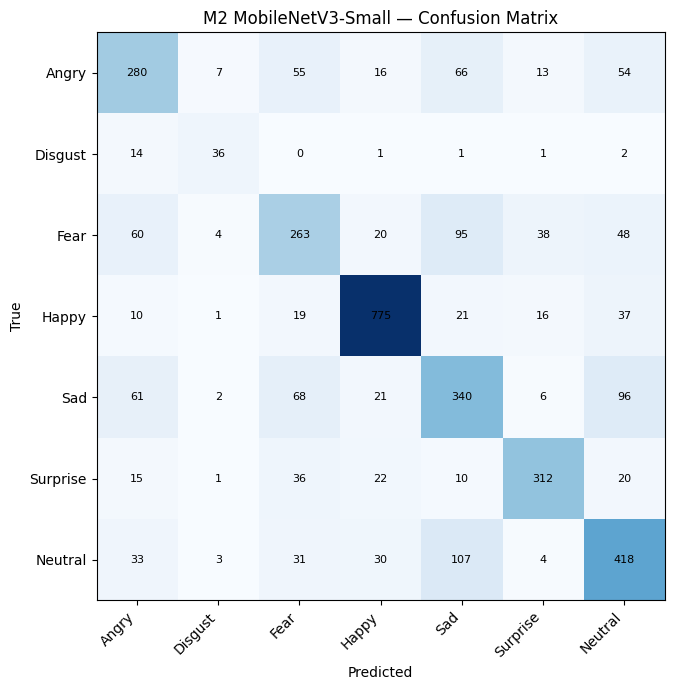

In [37]:

# 15. Confusion matrix

cm = confusion_matrix(
    test_metrics["y_true"],
    test_metrics["y_pred"],
)

plt.figure(figsize=(8, 7))
plt.imshow(cm, cmap="Blues")
plt.title("M2 MobileNetV3-Small — Confusion Matrix")

plt.xticks(
    range(NUM_CLASSES),
    FER_LABELS,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(NUM_CLASSES),
    FER_LABELS,
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j, i, cm[i, j],
            ha="center",
            va="center",
            fontsize=8,
        )

plt.tight_layout()
plt.show()


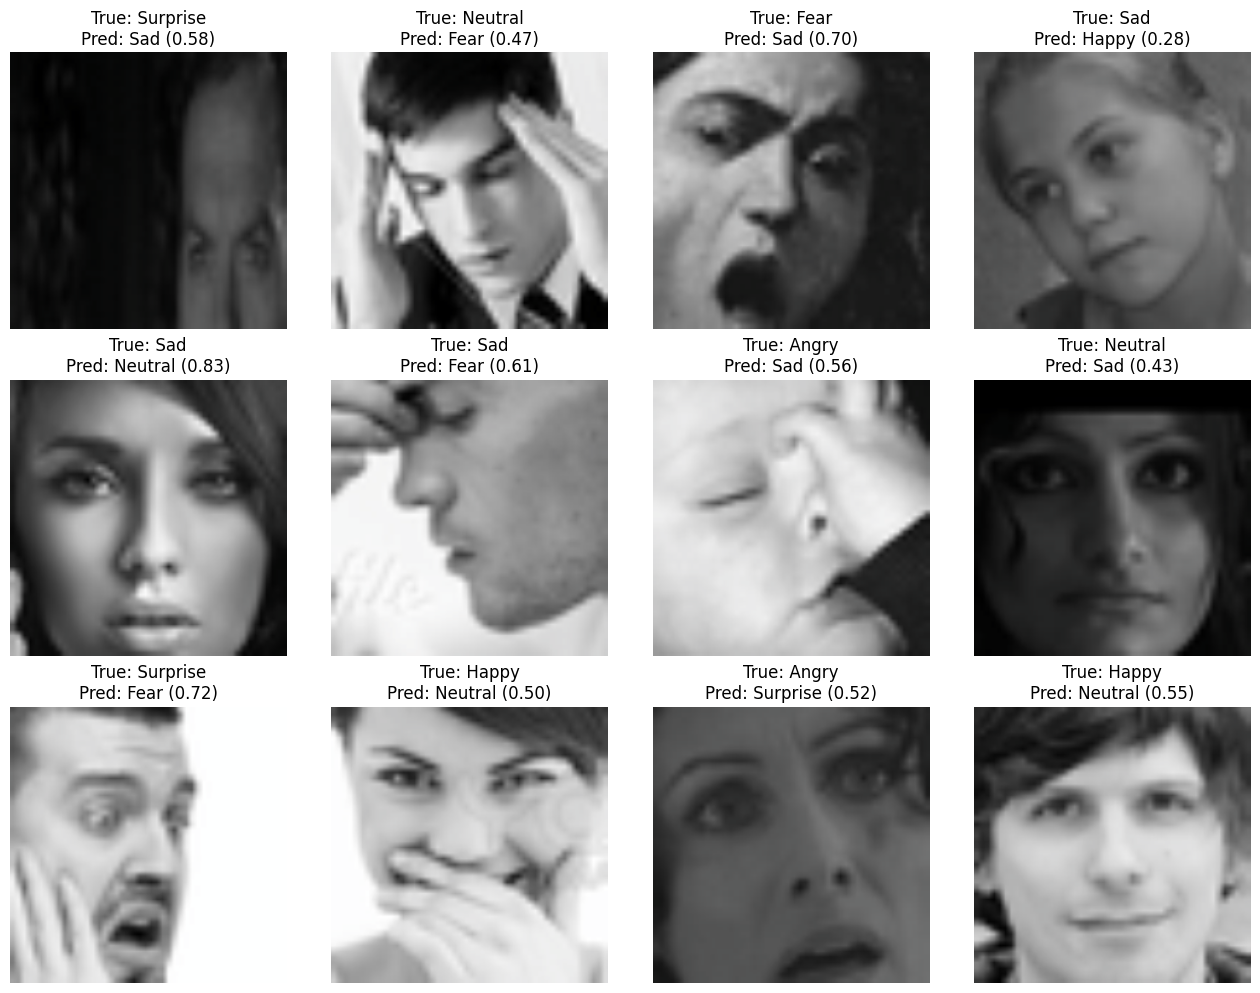

In [38]:

# 16. Show at least 10 misclassified PrivateTest samples

@torch.no_grad()
def collect_misclassified(model, dataset, n=12):
    model.eval()
    found = []

    for idx in range(len(dataset)):
        x, y = dataset[idx]

        logits = model(
            x.unsqueeze(0).to(DEVICE)
        )

        probs = torch.softmax(logits, dim=1)[0]
        pred = int(probs.argmax().item())

        if pred != int(y):
            found.append({
                "index": idx,
                "image": x.cpu(),
                "true": int(y),
                "pred": pred,
                "confidence": float(probs[pred].item()),
            })

            if len(found) >= n:
                break

    return found

wrong = collect_misclassified(
    model,
    test_ds,
    n=12,
)

fig, axes = plt.subplots(
    3, 4,
    figsize=(13, 10),
)

for ax, item in zip(axes.ravel(), wrong):
    x = item["image"].numpy().transpose(1, 2, 0)
    x = x * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    x = np.clip(x, 0, 1)

    ax.imshow(x)
    ax.set_title(
        f"True: {FER_LABELS[item['true']]}\n"
        f"Pred: {FER_LABELS[item['pred']]} "
        f"({item['confidence']:.2f})"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


In [39]:

# 17. CPU classifier benchmark

cpu_model = copy.deepcopy(model).cpu().eval()
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)

with torch.inference_mode():
    for _ in range(50):
        _ = cpu_model(dummy)

times = []

with torch.inference_mode():
    for _ in range(300):
        t0 = time.perf_counter()
        _ = cpu_model(dummy)
        times.append(time.perf_counter() - t0)

latency_ms = float(np.mean(times) * 1000.0)
classifier_fps = float(1.0 / np.mean(times))

print(f"Parameters     : {PARAM_COUNT:,}")
print(f"CPU latency    : {latency_ms:.2f} ms/face")
print(f"Classifier FPS : {classifier_fps:.2f}")
print("Classifier FPS != full realtime pipeline FPS.")


Parameters     : 1,525,031
CPU latency    : 10.22 ms/face
Classifier FPS : 97.81
Classifier FPS != full realtime pipeline FPS.


In [40]:

# 18. Save final summary

summary = {
    "model": "MobileNetV3Small",
    "pretrained": "ImageNet",
    "best_epoch": int(best_ckpt["epoch"]),
    "best_stage": best_ckpt["stage"],
    "val_accuracy": float(best_ckpt["val_accuracy"]),
    "val_macro_f1": float(best_ckpt["val_macro_f1"]),
    "test_accuracy": float(test_metrics["accuracy"]),
    "test_macro_f1": float(test_metrics["macro_f1"]),
    "parameters": int(PARAM_COUNT),
    "cpu_latency_ms_per_face": float(latency_ms),
    "classifier_fps_cpu": float(classifier_fps),
    "batch_size": int(BATCH_SIZE),
    "gpu_count_used": 1 if torch.cuda.is_available() else 0,
    "amp": bool(USE_AMP),
    "labels": FER_LABELS,
    "input_size": [3, IMG_SIZE, IMG_SIZE],
}

with open(
    OUTPUT_DIR / "FINAL_SUMMARY.json",
    "w",
) as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))


{
  "model": "MobileNetV3Small",
  "pretrained": "ImageNet",
  "best_epoch": 33,
  "best_stage": "finetune",
  "val_accuracy": 0.6567288938422959,
  "val_macro_f1": 0.6432681047691705,
  "test_accuracy": 0.6753970465310671,
  "test_macro_f1": 0.6591396843970719,
  "parameters": 1525031,
  "cpu_latency_ms_per_face": 10.22387907666901,
  "classifier_fps_cpu": 97.81023352300883,
  "batch_size": 128,
  "gpu_count_used": 1,
  "amp": true,
  "labels": [
    "Angry",
    "Disgust",
    "Fear",
    "Happy",
    "Sad",
    "Surprise",
    "Neutral"
  ],
  "input_size": [
    3,
    224,
    224
  ]
}


### M2 final result

- Test Accuracy: **67.54%**
- Macro F1: **0.6591**
- Parameters: **1,525,031**
- CPU Predictor FPS: **97.81**

M2 converts FER-2013 grayscale images to RGB, resizes them to 224×224, applies ImageNet normalization and fine-tunes an ImageNet-pretrained MobileNetV3-Small.


# Part C — M3: Comparison of M1 and M2

| Metric | M1 FERAttentionLite | M2 MobileNetV3-Small |
|---|---:|---:|
| Test Accuracy | **68.54%** | **67.54%** |
| Macro F1 | **0.6690** | **0.6591** |
| Parameters | **1,211,033** | **1,525,031** |
| CPU Predictor FPS | **211.05** | **97.81** |

### Discussion

M1 achieved slightly better accuracy and macro F1 while also being smaller and faster in the measured CPU predictor benchmark. In this experiment, the FER-specific custom CNN matched the low-resolution grayscale domain better than the generic ImageNet-pretrained backbone.

M2 still exceeded the required **65%** test-accuracy threshold, so both models satisfy the assignment requirements.


# Part D — M4: Error Analysis

The confusion matrices and misclassified-image examples are preserved in the M1 and M2 sections above.

### Main observations

Common difficult pairs include:

- Fear → Sad
- Sad ↔ Neutral
- Angry → Sad
- Fear → Surprise

FER-2013 contains only 48×48 grayscale facial images, so subtle eye, eyebrow and mouth cues can be ambiguous. Low contrast, pose variation and visually similar expressions also contribute to these errors.

The model sections include at least 10 misclassified PrivateTest examples with the true label, predicted label and confidence.


# Part E — M5: Training Curves

The executed training curves for both models are preserved in their respective sections:

- training loss vs validation loss,
- training accuracy vs validation accuracy,
- validation macro F1.

For M2, the Stage 1/Stage 2 transition is also shown, making the transfer-learning process visible.


# Final Conclusion

Both required models meet the assignment thresholds:

- **M1 FERAttentionLite:** 68.54% test accuracy ≥ 60%.
- **M2 MobileNetV3-Small:** 67.54% test accuracy ≥ 65%.

The experiment shows that transfer learning is not automatically superior on every dataset. A compact architecture designed specifically for low-resolution grayscale facial-expression data can be competitive with, or slightly outperform, a generic ImageNet-pretrained backbone.
